In [1]:
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import PolynomialLR
from torch.utils.data import WeightedRandomSampler
from torchvision.transforms import v2

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm.notebook import tqdm
import json
import cv2
import numpy as np
###IE###
%load_ext autoreload
%autoreload 2
from utils.helpers import  plot_some_images ,read_images , pre_hard_skeletonize , pre_soft_skeletonize,compute_confution_matrix
from utils.preprocessing import WhiteTopHat , CLAHE , normalize_xca
from utils.dataset import  UnetDataset , ValidUnetDataset
from models.nnunet import nnUnet
from models.nnunet_blocks import nnUnetv2
from models.swin_encoder import SwinEncoder , SwinUperNet
from utils.losses import UnetLoss
from utils.recorder import HistoryRecorder
from logger import save_full_report
from trainer import trainer
###SS###

# Training

In [2]:
args = {
    "base_path" : "../arcade/nnUnet_dataset/syntax",
    "in_c" : 3,
    "base_channel" :32,
    "image_shape" : (384,384),
    "class_count" : 26 ,
    "attention" : True,
    "k":40,
    "batch_size" : 8,
    "num_workers" : 10,
    "device" : "cuda" if torch.cuda.is_available() else "cpu",
    "lr" : 0.001,
    "momentum" : 0.99,
    "weight_decay" : 0.001,
    "epcohs":30,
    "f_int_scale" : 2,
    "full_report_cycle" : 10,
    "max_channels":512,
    "unet_depth":6,
    "loss_type":"tversky loss",
    "alpha":0.3,
    "beta":0.7,
    "t_gamma":2.0,
    "f_gamma":2.0,
    "f_loss_scale":1,
    "loss_coefs":{"CE":1.0,"Second":1.0},
    "swin_head" : "costume",
    "swin_type":"swin_v2_b",
    "output_base_path" : "./outputs",
    "name" : "Attention7-DSV-tev-new_augs-swin_upernet_base_img-FCE",
    "deep_super_vision" : False,
    "use_sch":False,
    "f_alpha":None
}
class_map = {
    1: '1',2: '2', 3: '3',4: '4',
    5: '5',6: '6',7: '7',8: '8',
    9: '9',10: '9a',11: '10',12: '10a',
    13: '11',14: '12',15: '12a',16: '13',
    17: '14',18: '14a',19: '15',20: '16',
    21: '16a',22: '16b',23: '16c',
    24: '12b',25: '14b'
}
train_class_counts = [
    1000,374,375,369,303,525,525,
    340,310,198,70,21,1,320,61,
    129,305,107,49,38,232,43,48,31,63,127
]
train_pixel_counts = [
    253576361,664435,686727,661957,
    480566,591829,816901,685677,570436,
    470633,124025,23866,1079,507754,151219,
    336857,597880,241117,98167,66890,322098,
    49426,63543,36457,164558,153542
]
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
# losses_keys = ["total loss","FCE loss",args["loss_type"]]
losses_keys = ["total loss","FCE loss",args["loss_type"]]
out_counts = 5 if args["deep_super_vision"] else 1
loss_weights = [1/(2**i) for i in range(out_counts)]
loss_weights

[1.0]

In [ ]:
def class_weighting(method,class_counts,**kwargs):
    if(kwargs["use_pixel_counts"]):
        print("using pixel counts")
        with open("./data/train_class_counts.json","r") as f:
            train_class_counts = json.load(f)
        counts = [0]*(len(train_class_counts))
        for k,v in train_class_counts.items():
            counts[int(k)] = int(v)
        counts = np.array(counts,dtype=np.float64)
    else :
        print("using class counts")
        counts = np.array(class_counts,dtype=np.float64)

    if(method=="median"):
        print("median weights being used")
        median_count = np.median(counts)
        weights = median_count/np.array(counts)
        
    elif(method=="log"):
        print("log weights being used")
        total = np.sum(counts)
        weights = np.log(total/np.array(counts))
        weights = (weights / weights.mean())
        weights[0]=0.1
    elif(method=="beta"):
        print("beta weights being used")
        b = kwargs["b"]
        weights = (1-b)/(1-np.power(b,counts))
        weights = weights / weights.sum()
        weights[12] = 0.25
    else:
        print("no class weights being used")
        return None
    return weights.tolist()
args["f_alpha"] = class_weighting(method="none",class_counts=train_class_counts,b=0.999999,use_pixel_counts=True)
args["f_alpha"]

using class counts
no class weights being used


In [4]:
# pre_soft_skeletonize(args["base_path"],output_path=args["base_path"],batch_size=10,k=40)

In [5]:
def morph_binary_mask(x, **kwargs):
    m = x.copy()

    if m.ndim == 3:
        m2 = m[..., 0]
    else:
        m2 = m

    m2 = (m2 > 0).astype(np.uint8)

    if np.random.rand() < 0.5:
        k = np.ones((3, 3), np.uint8)
        if np.random.rand() < 0.5:
            m2 = cv2.dilate(m2, k, iterations=1)
        else:
            m2 = cv2.erode(m2, k, iterations=1)

    if np.random.rand() < 0.5:
        blurred = cv2.GaussianBlur(m2.astype(np.float32), (3, 3), 0)
        m2 = (blurred > 0.5).astype(np.uint8)

    if np.random.rand() < 0.5:
        h, w = m2.shape        
        for _ in range(200):
            y = np.random.randint(0, h)
            x = np.random.randint(0, w)
            m2[y, x] = 0

    
    if m.ndim == 3:
        m_out = m2[..., None]
    else:
        m_out = m2

    return m_out

In [6]:
train_transforms = A.Compose([
    # A.RandomCrop(args["image_shape"][0],args["image_shape"][1]),
    A.Resize(*args["image_shape"]),
    A.OneOf([
        A.ElasticTransform(
            alpha=120, 
            sigma=120 * 0.05, 
            p=1.0
        ),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
        A.OpticalDistortion(distort_limit=0.2, p=1.0),
    ], p=0.7),


    A.Affine(
        scale=(0.8, 1.2),             
        translate_percent=(-0.1, 0.1), 
        rotate=(-30, 30),         
        shear=(-10, 10),      
        

        fill=0,           
        fill_mask=0,                 
        border_mode=cv2.BORDER_CONSTANT, 
        
        fit_output=False,  
        p=0.7
    ),

    # A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),

    # A.RandomBrightnessContrast(
    #     brightness_limit=0.2, 
    #     contrast_limit=0.2, 
    #     p=0.5
    # ),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    # A.Lambda(image=morph_binary_mask, p=1),

    # A.Lambda(image=normalize_xca)
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
                max_pixel_value=255.0
    ),
    ToTensorV2()

])
test_transforms = A.Compose([
    # A.RandomCrop(args["image_shape"][0],args["image_shape"][1]),
    A.Resize(*args["image_shape"]),
    # A.Lambda(image=normalize_xca),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
                max_pixel_value=255.0
                ),
    ToTensorV2(),
    ]  
)
# train_preprocess = v2.Compose([
#     WhiteTopHat(kernel_size=(50,50)),
#     CLAHE()
    
# ])
train_preprocess = None


In [7]:
def make_dataloader(data,args,valid=False,sampler_weights=None):
    if(sampler_weights is not None):
        print("using weighted sampler here")
        sampler = WeightedRandomSampler(sampler_weights, len(sampler_weights))
        dataloader = DataLoader(
            data,
            batch_size = args["batch_size"] ,
            num_workers = args["num_workers"] ,
            pin_memory=True,
            shuffle=False,
            sampler=sampler
        )
        
    else : 
        if(valid):
            print("valid with no sampler")
            dataloader = DataLoader(
                data,
                batch_size = args["batch_size"] ,
                num_workers = args["num_workers"] ,
                pin_memory=True,
                shuffle=False,
            )
        else : 
            print("train with no sampler")
            dataloader = DataLoader(
                data,
                batch_size = args["batch_size"] ,
                num_workers = args["num_workers"] ,
                pin_memory=True,
                shuffle=True
            )
    return dataloader

In [8]:

train_images,sampler_weights = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "train",
    train_class_counts=np.array(train_pixel_counts),
    in_c = args["in_c"]
    # mode = args["train_mode"]
)
valid_images = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "val",
    train_class_counts=None,
    in_c=args["in_c"]
    # mode = args["train_mode"]
)
# print(sampler_weights)
train_ds = UnetDataset(transform = train_transforms,data = train_images,base_size=args["image_shape"][0],out_counts=out_counts)
valid_ds = ValidUnetDataset(transform = test_transforms,data = valid_images)

train_loader = make_dataloader(train_ds,args,valid=False,sampler_weights=sampler_weights)
valid_loader = make_dataloader(valid_ds,args,valid=True,sampler_weights=None)

max count is :  816901
NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/1000 [00:00<?, ?it/s]

NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/200 [00:00<?, ?it/s]

using weighted sampler here
valid with no sampler


In [9]:
# plot_some_images(train_images, train_transforms, mean=IMAGENET_MEAN,std=IMAGENET_STD,image_counts=36, fig_shape=(6,6), base_transforms=test_transforms)

In [10]:
model = SwinUperNet(args).to(args["device"])

loss_fn = UnetLoss(args)
# optimizer = torch.optim.Adam(model.parameters(), lr=args["lr"])
# optimizer = torch.optim.SGD(
#     model.parameters(),
#     momentum=args["momentum"],
#     lr=args["lr"],
#     nesterov=True,
#     weight_decay=args["weight_decay"]
# )
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=args["lr"], 
    betas=(0.9, 0.999), 
    eps=1e-08, 
    weight_decay=args["weight_decay"]
)
if(args["use_sch"]):
    lr_sch = PolynomialLR(optimizer=optimizer,total_iters=args["epcohs"],power=0.9)
else:
    lr_sch = None
recorder = HistoryRecorder(losses_keys=losses_keys,class_maps =class_map)

best_model =trainer(
    args=args,
    recorder = recorder,
    model = model,
    optimizer = optimizer,
    loss_fn = loss_fn,
    train_loader = train_loader,
    valid_loader = valid_loader,
    loss_weights=loss_weights,
    lr_sch = lr_sch
)

loss is set to tversky


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]

current lr : 0.001
train ==> epcoh (0)
total loss : 1.528124762058258 - FCE loss : 0.6071995174884797 - tversky loss : 0.9209252514839172

train avg metrics for epoch 0 :
avg dice : 0.0441330047604417 - avg precision : 0.059768562652170655 - avg recall : 0.05272549755871296
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (0)
total loss : 1.2765142488479615 - FCE loss : 0.30751500725746156 - tversky loss : 0.9689992380142212

valid avg metrics for epoch 0 :
avg dice : 0.01678859663267889 - avg precision : 0.020158307179808616 - avg recall : 0.01742847549263388
------------------------------------------------------------
New Best! : dice = 0.016788596287369728


  0%|          | 0/125 [00:00<?, ?it/s]

...

--- Total Norm ---
tensor(0.5096, device='cuda:0')
--- Total Norm ---
tensor(0.5543, device='cuda:0')
current lr : 0.001
train ==> epcoh (27)
total loss : 0.4788603885173798 - FCE loss : 0.07936546331644058 - tversky loss : 0.3994949254989624

train avg metrics for epoch 27 :
avg dice : 0.49882342040538785 - avg precision : 0.46194205701351165 - avg recall : 0.5470669364929199
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (27)
total loss : 0.5831084108352661 - FCE loss : 0.09434964418411255 - tversky loss : 0.48875876545906066

valid avg metrics for epoch 27 :
avg dice : 0.36365616591647265 - avg precision : 0.3694693483412266 - avg recall : 0.4092067571543157
------------------------------------------------------------
New Best! : dice = 0.3636561632156372


  0%|          | 0/125 [00:00<?, ?it/s]

current lr : 0.001
train ==> epcoh (28)
total loss : 0.4761076979637146 - FCE loss : 0.07783291971683502 - tversky loss : 0.3982747793197632

train avg metrics for epoch 28 :
avg dice : 0.49039110898971555 - avg precision : 0.45480688750743864 - avg recall : 0.5373929423093796
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (28)
total loss : 0.5847483646869659 - FCE loss : 0.08832597181200981 - tversky loss : 0.49642238855361936

valid avg metrics for epoch 28 :
avg dice : 0.3620971857011318 - avg precision : 0.3579297049343586 - avg recall : 0.4019454590976238
------------------------------------------------------------


  0%|          | 0/125 [00:00<?, ?it/s]

current lr : 0.001
train ==> epcoh (29)
total loss : 0.49609727692604066 - FCE loss : 0.08125984489917755 - tversky loss : 0.41483743476867674

train avg metrics for epoch 29 :
avg dice : 0.4849429476261139 - avg precision : 0.4469267100095749 - avg recall : 0.5349373292922973
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (29)
total loss : 0.5706205296516419 - FCE loss : 0.08927696764469147 - tversky loss : 0.48134355902671816

valid avg metrics for epoch 29 :
avg dice : 0.36838454090058803 - avg precision : 0.3722448097169399 - avg recall : 0.4034184771776199
1 => dice : 0.7559229731559753 p : 0.7386818528175354 , r : 0.7739881277084351
2 => dice : 0.699454665184021 p : 0.7224773168563843 , r : 0.6778540015220642
3 => dice : 0.6856719851493835 p : 0.661965012550354 , r : 0.7111400961875916
4 => dice : 0.5148969888687134 p : 0.39154502749443054 , r : 0.7517171502113342
5 => dice : 0.69418865442276 p : 0.65257328748703 , r : 0.7414733171463013
6 => dice : 

Save Model
Saving Memory
Saving All Plots
Saving Examples
Saving Verbal Results
Copying Notebook To Results
builfding kaggle project


100%|██████████| 11/11 [00:00<00:00, 2574.48it/s]


processing ./utils/dataset.py
processing ./utils/helpers.py
processing ./logger.py
processing ./utils/preprocessing.py
processing ./utils/recorder.py
processing ./models/costume_nnunet_blocks.py
processing ./models/nnunet.py
processing ./models/swin_encoder.py
processing ./models/swin_blocks.py
processing ./utils/losses.py
processing ./trainer.py


100%|██████████| 1/1 [00:00<00:00,  4.08it/s]

processing ./temp_script.py


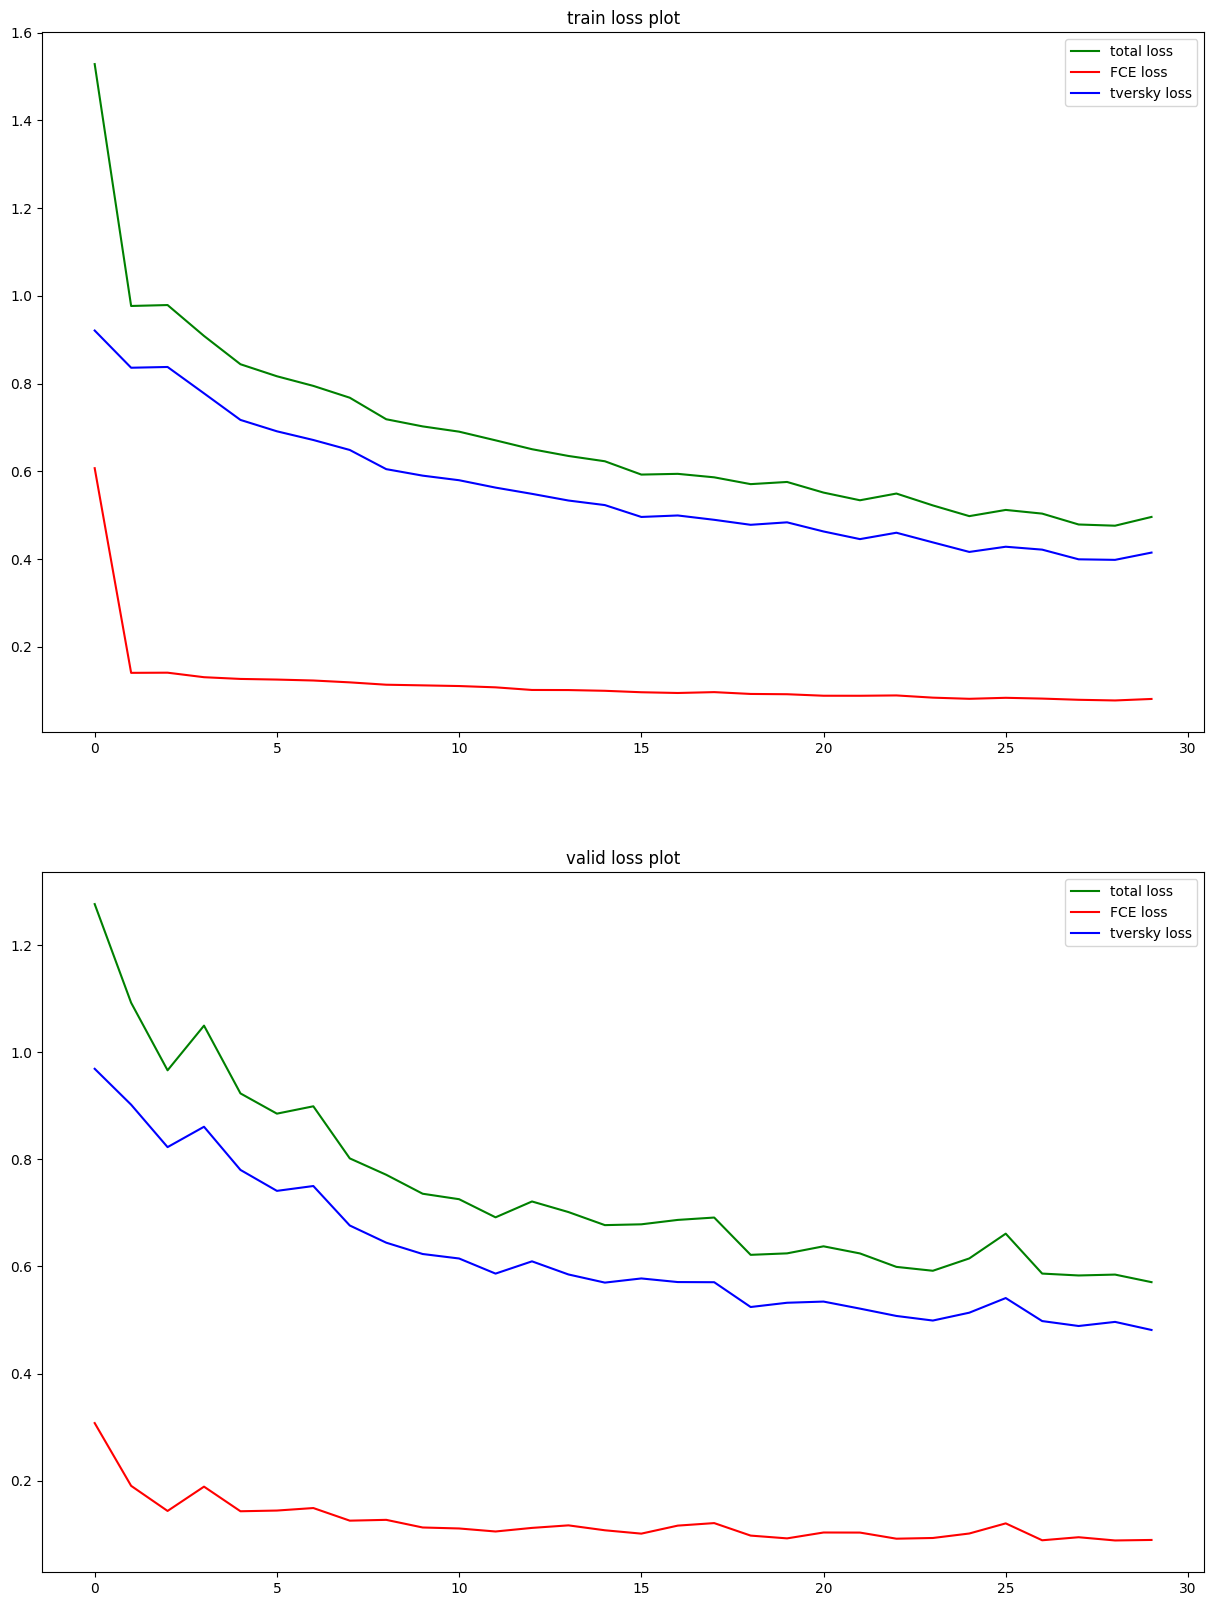

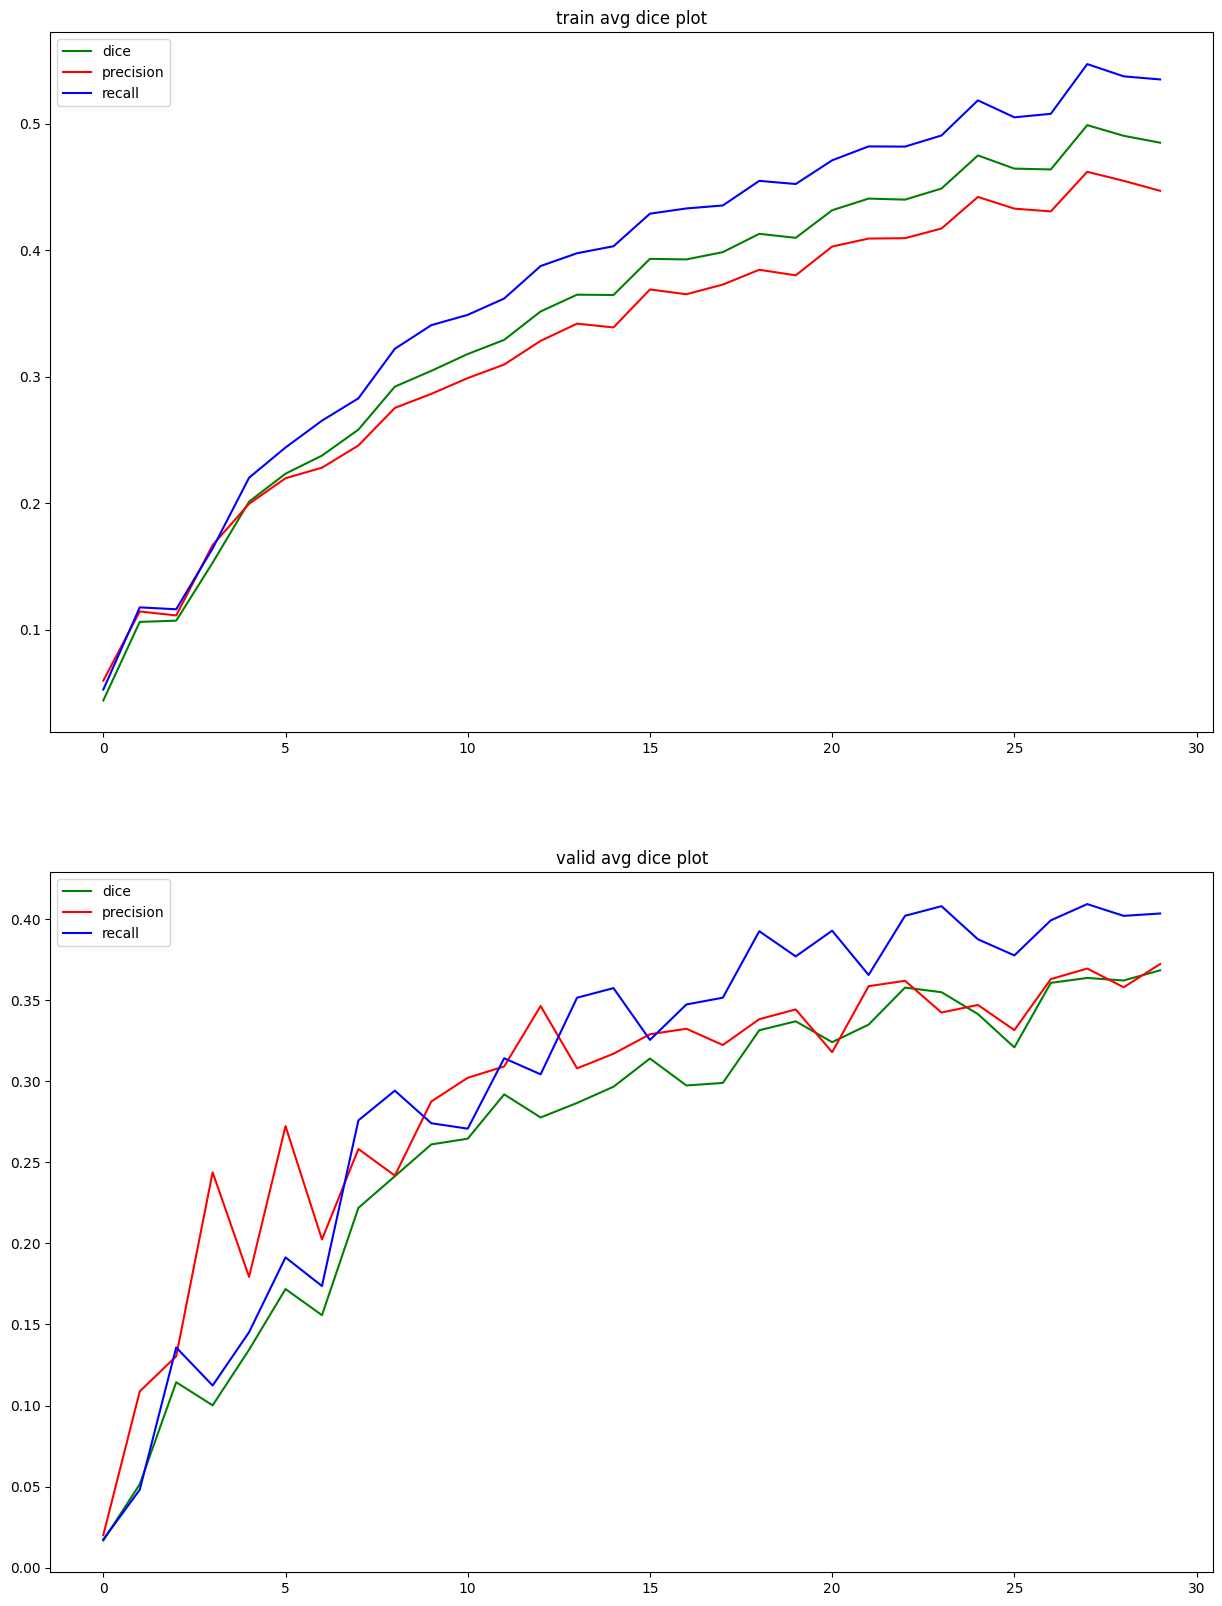

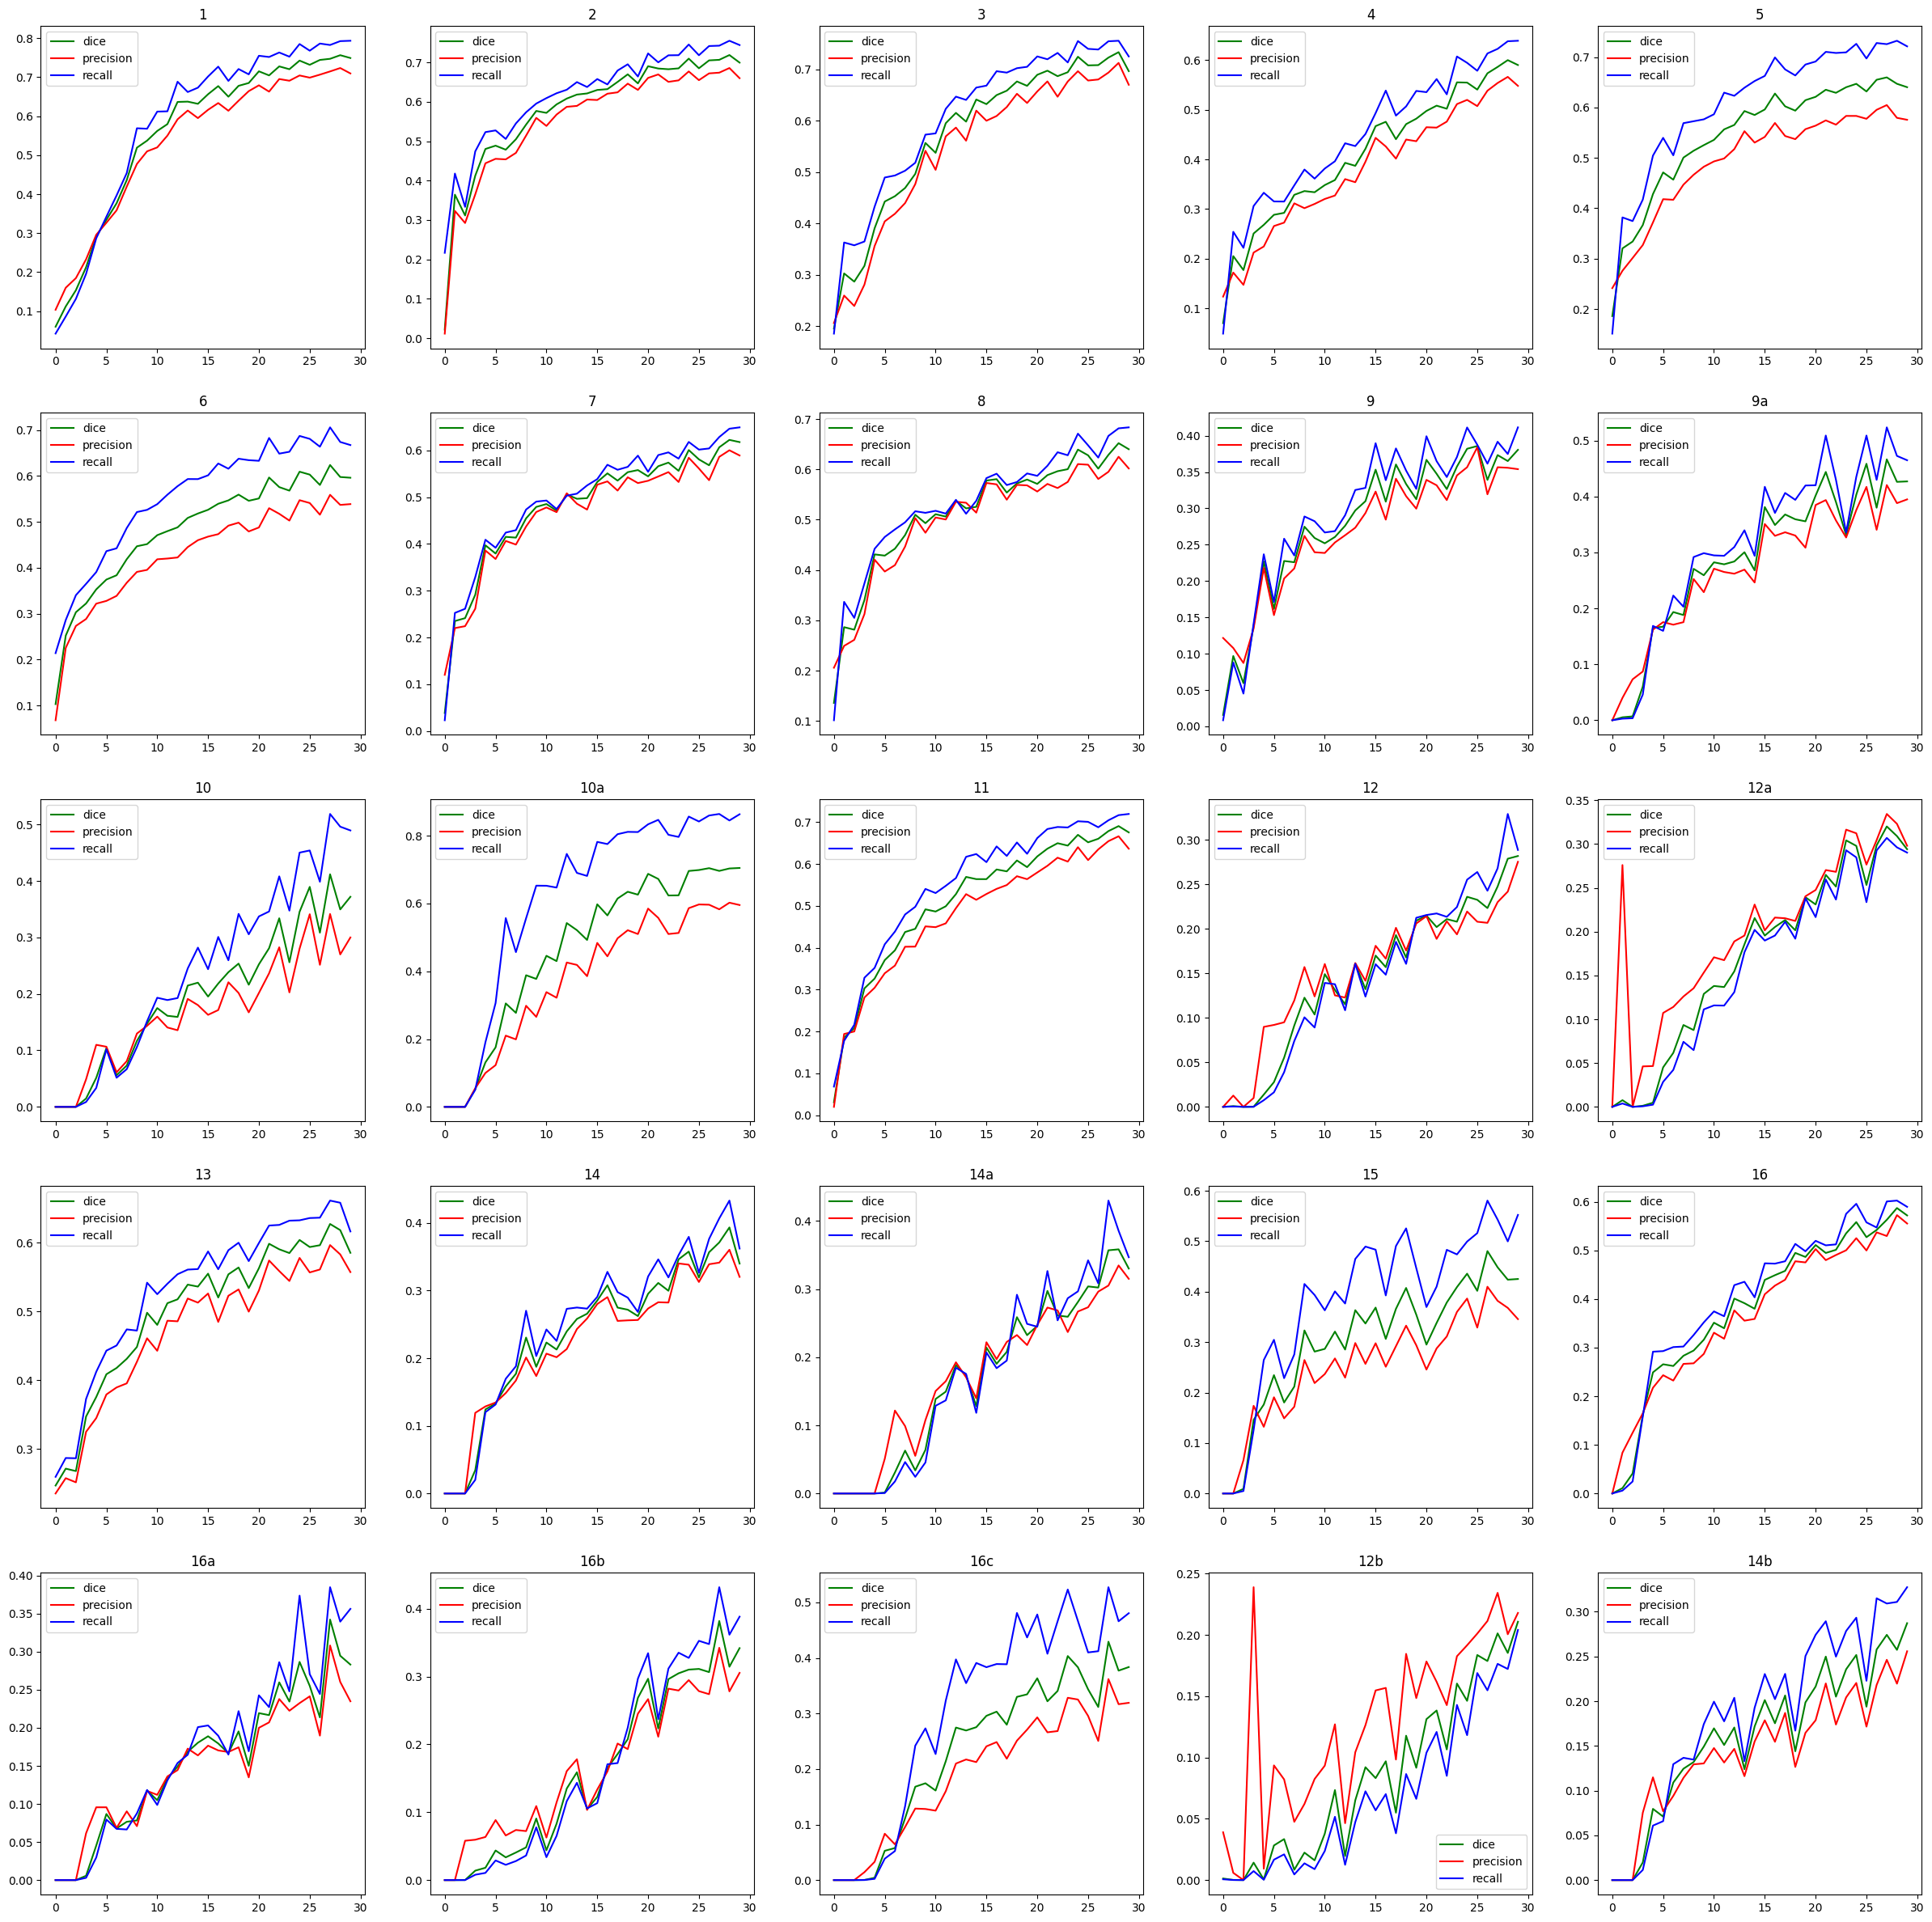

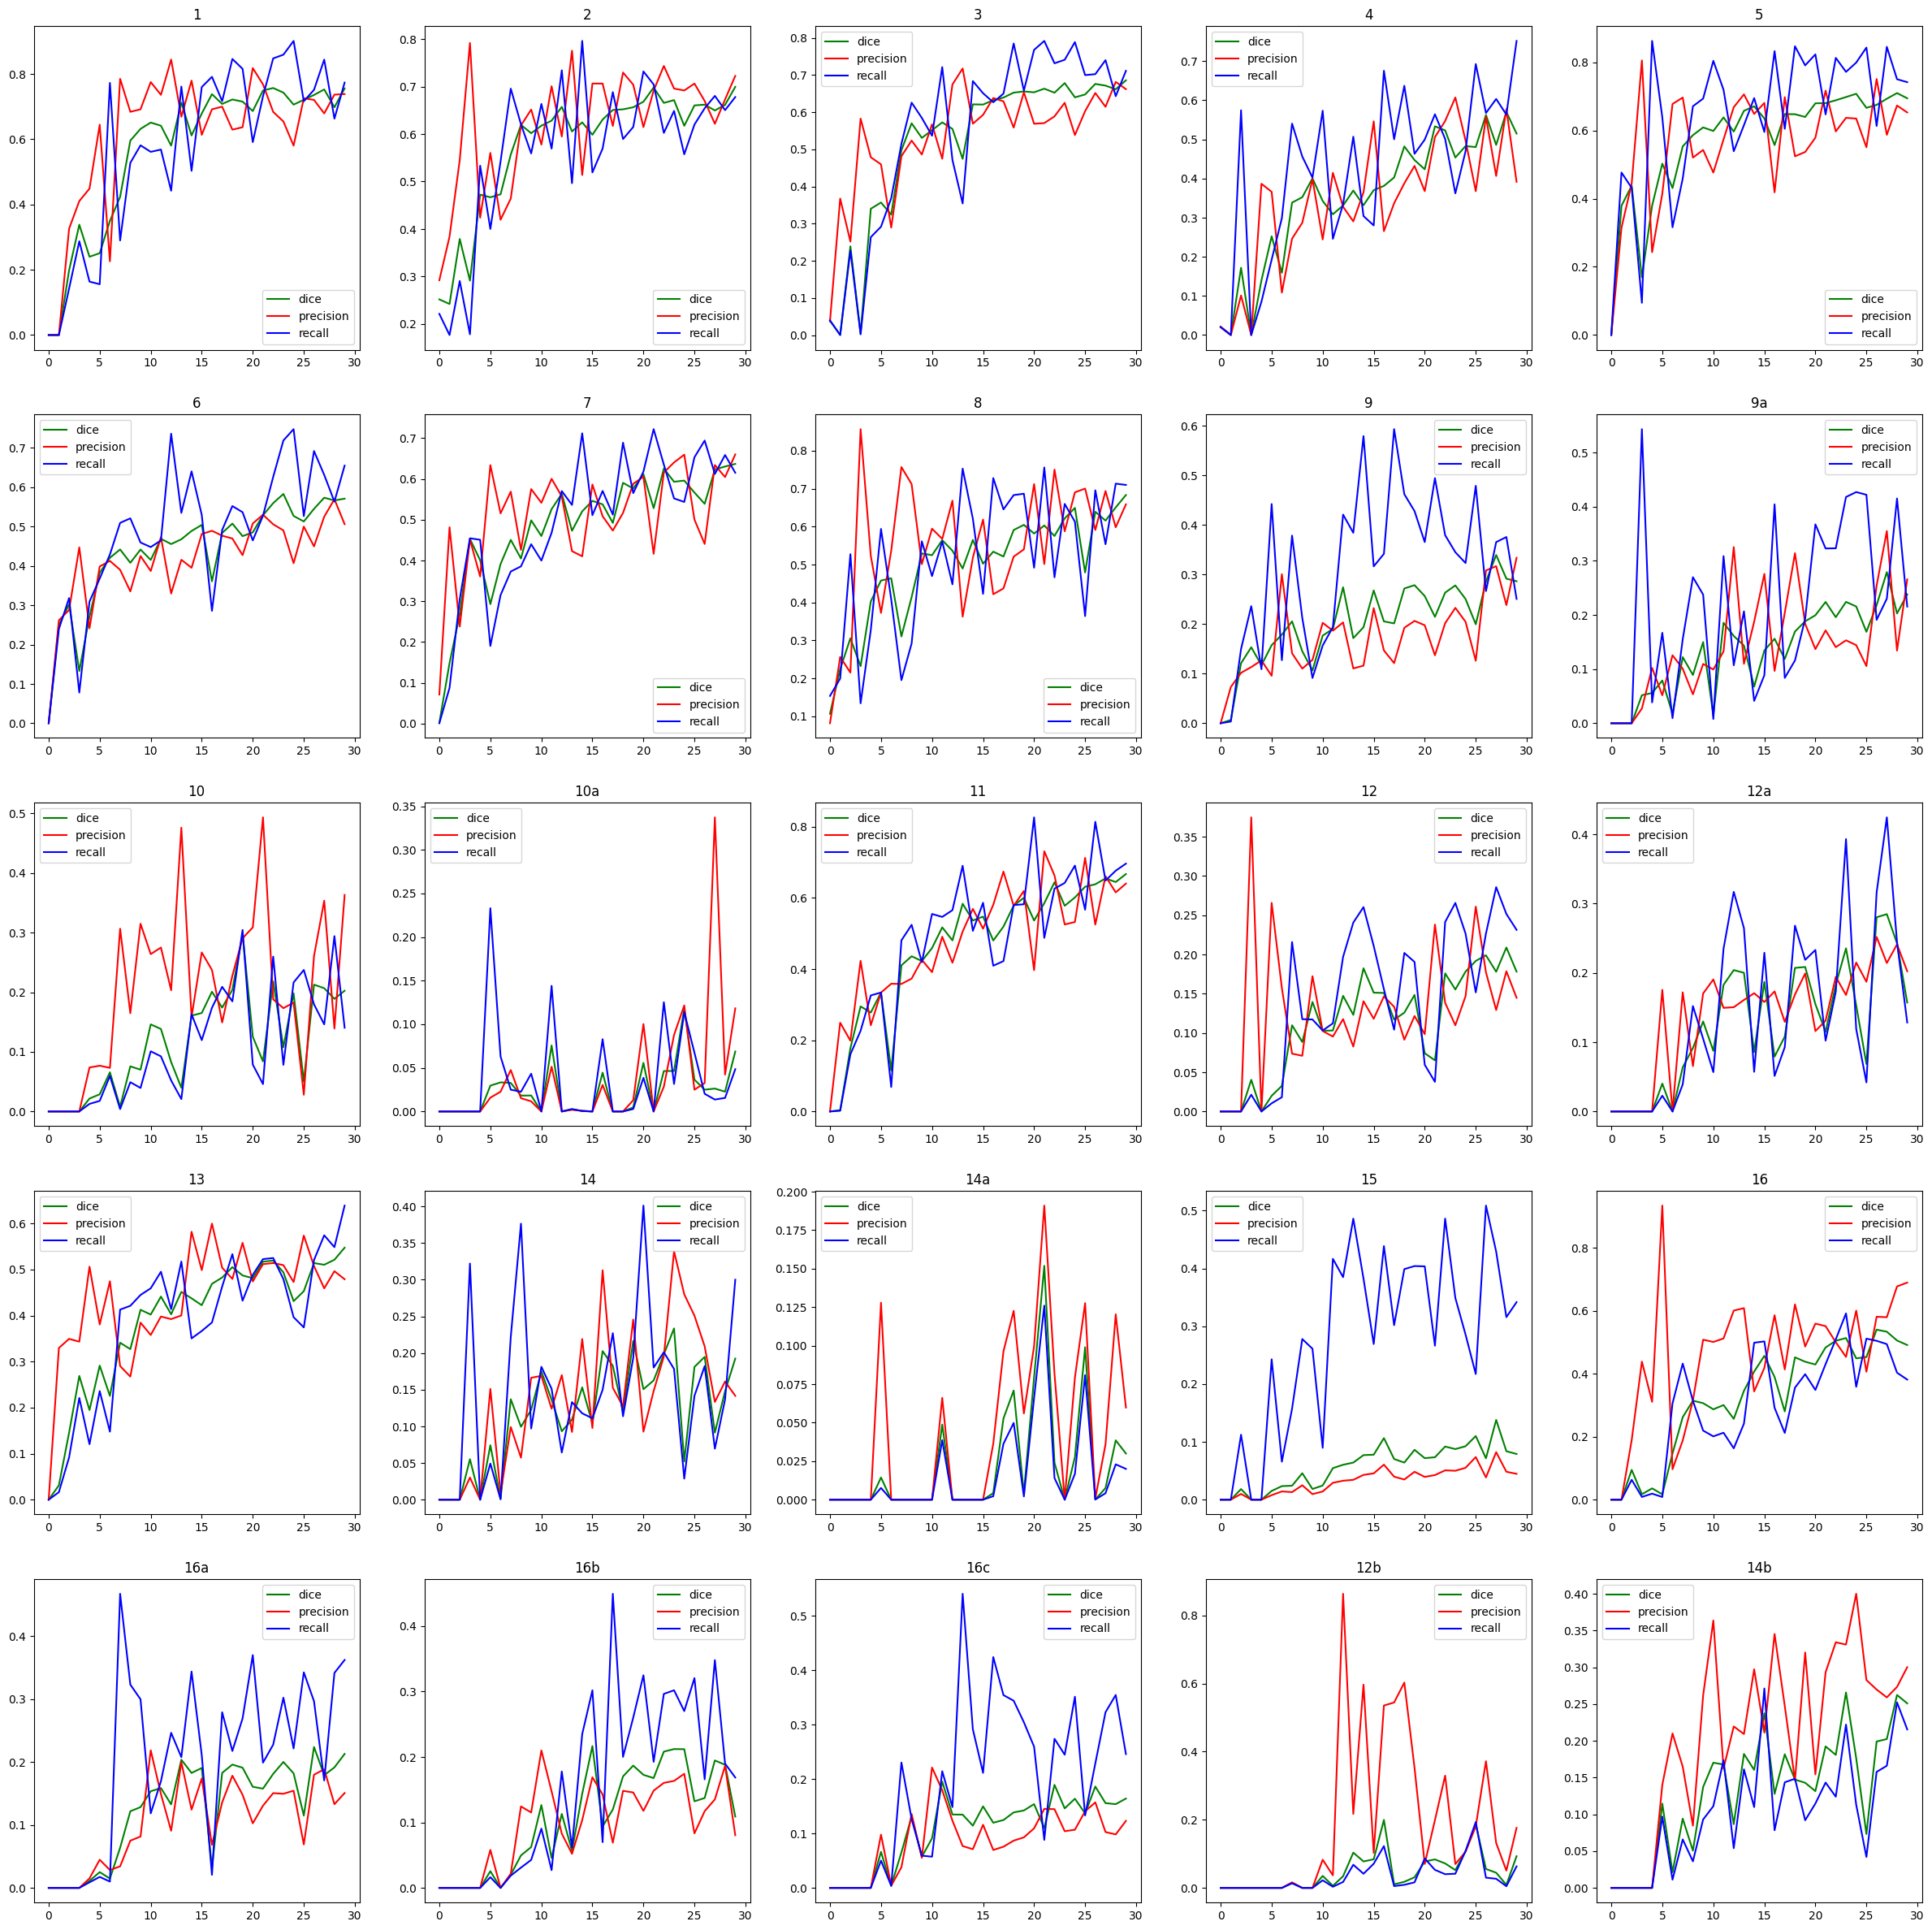

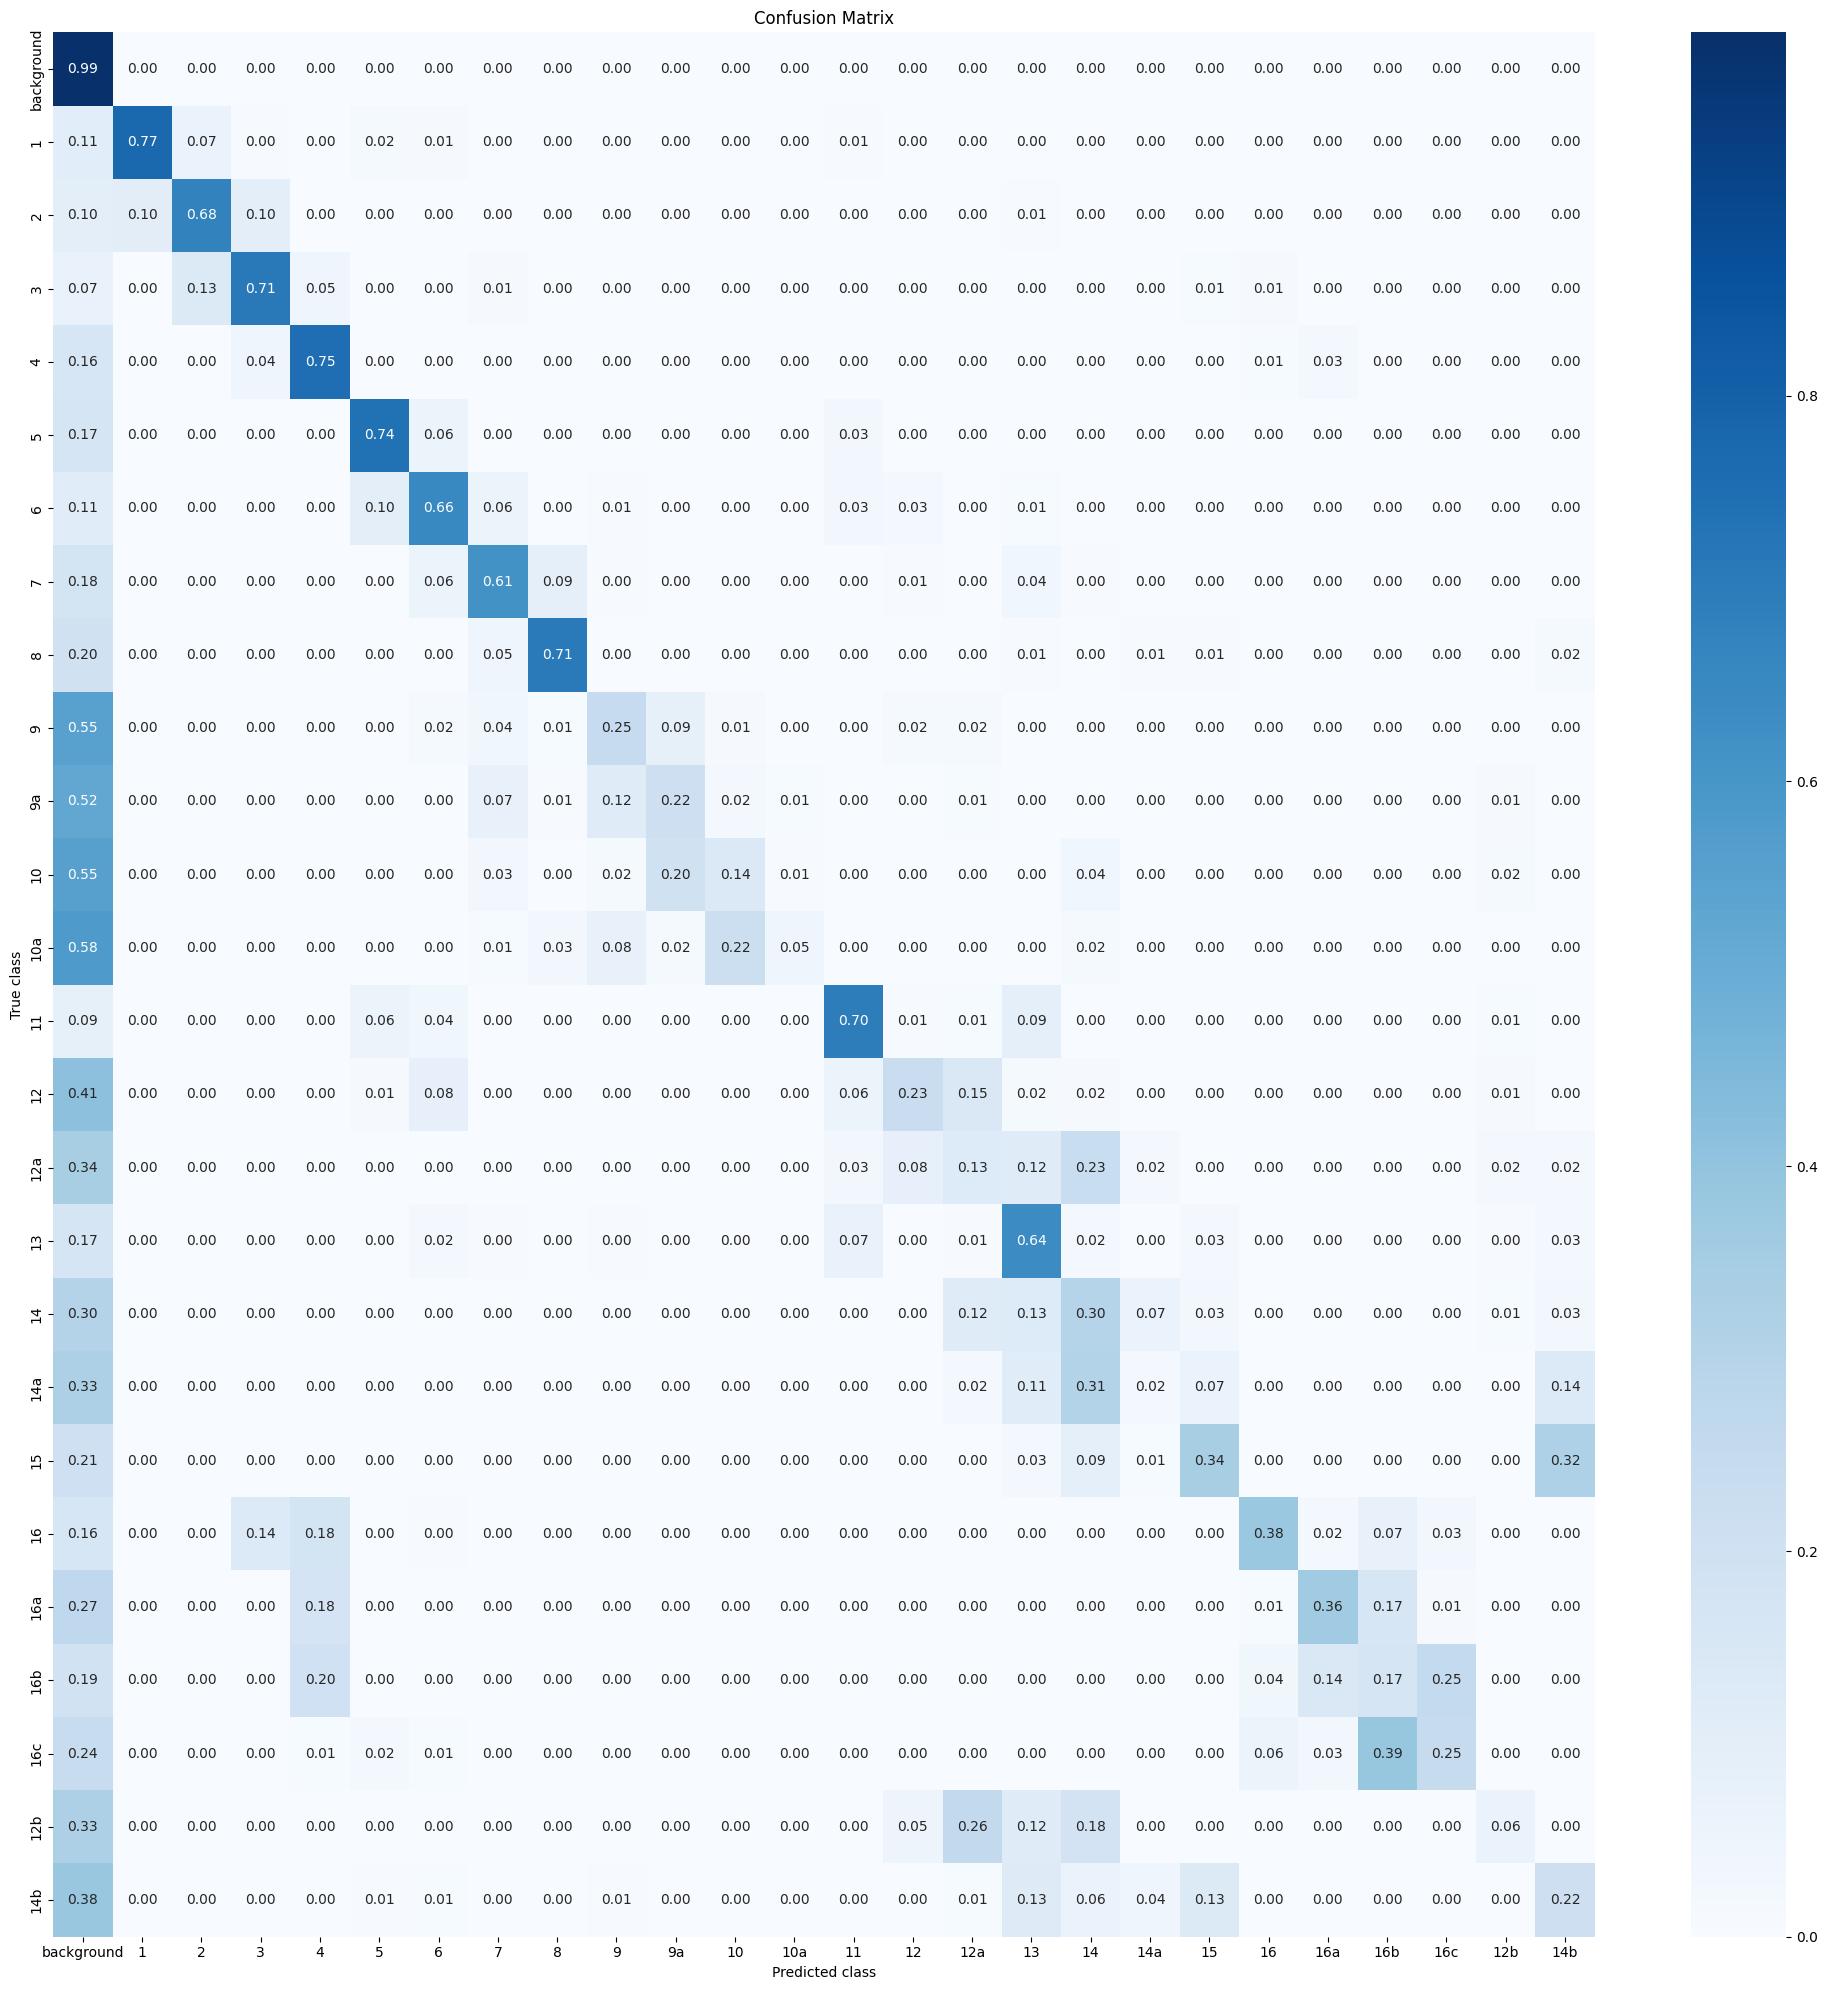

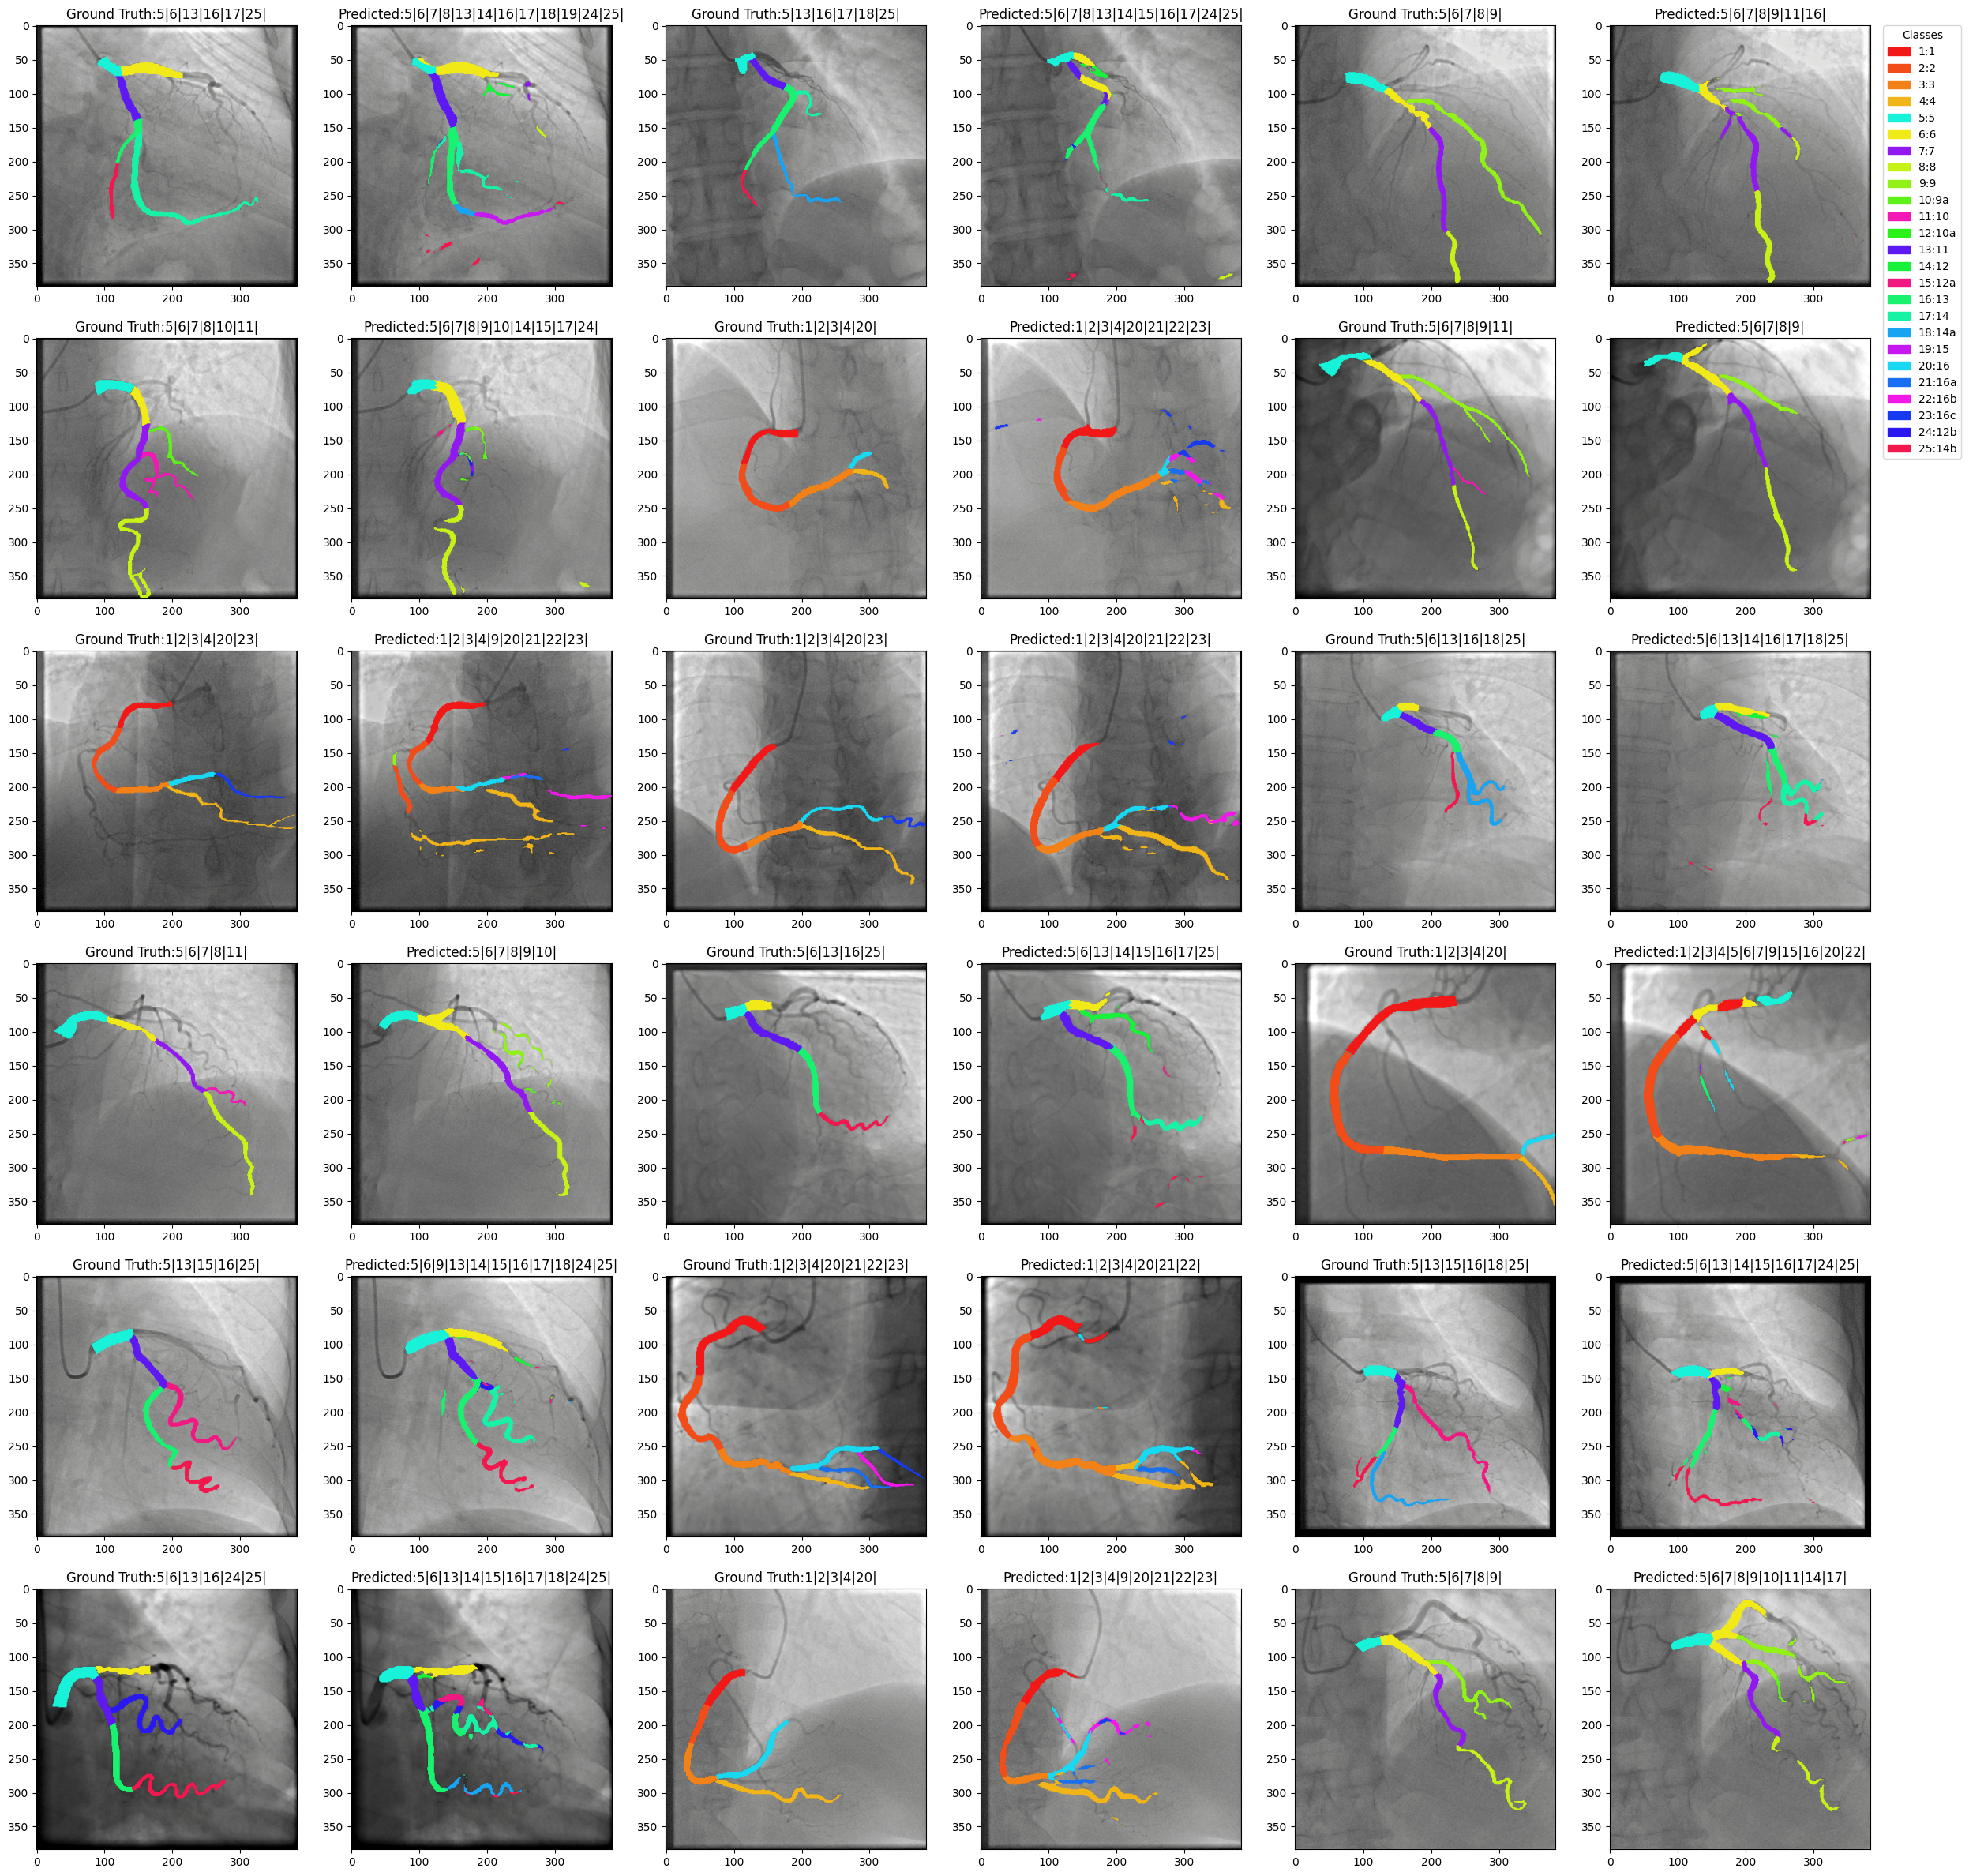

In [11]:
save_full_report(
    recorder= recorder , 
    output_base_path=args["output_base_path"],
    model=best_model,
    valid_loader=valid_loader,
    args=args,
    class_map=class_map,
    name=args["name"],
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD
)